# LeNet-5 Plus Evaluation and Visualization

In [ ]:
import os
import sys

import pandas as pd
import tensorflow as tf

# Add the parent directory to the Python path to allow imports from sibling directories
sys.path.append(os.path.abspath(".."))

from data.dataset import prepare_cifar10_dataset
from models.lenet5plus import LeNet5Plus
from utils.trainer import LeNetTrainer
from utils.visualize import plot_training_hist_df, plot_confusion_matrix, plot_sample_predictions

# Check TensorFlow version and available devices
print("TensorFlow Version:", tf.__version__)
print("Devices available:", tf.config.list_physical_devices())

TensorFlow Version: 2.21.0
Devices available: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## Evaluation on CIFAR-10 dataset

In [2]:
DATASET_NAME = "cifar10"
BATCH_SIZE = 64

_, _, test_ds = prepare_cifar10_dataset(batch_size=BATCH_SIZE)
input_shape = (32, 32, 3)

print(f"\nSuccessfully loaded CIFAR-10 data pipelines.")

CIFAR-10 Raw Shapes: (50000, 32, 32, 3) (50000,) (10000, 32, 32, 3) (10000,)

Successfully loaded CIFAR-10 data pipelines.


In [3]:
# Paths for saved model and weights
BEST_MODEL_PATH_CIF = f"../saved_models/lenet5_{DATASET_NAME}_best_model.keras"

# Option A: Load full saved model (.keras)
if os.path.exists(BEST_MODEL_PATH_CIF):
    model = tf.keras.models.load_model(BEST_MODEL_PATH_CIF)
    print("Best model loaded successfully.")
else:
    raise FileNotFoundError("No saved model or weights found. Please train the model first.")

Best model loaded successfully.


In [5]:
# Display network architecture summary
model.summary()

Model: "LeNet5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C1_Conv (Conv2D)                │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ S2_MaxPool (MaxPooling2D)       │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C3_Conv (Conv2D)                │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ S4_MaxPool (MaxPooling2D)       │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C5_Conv (Conv2D)                │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GAP (GlobalAveragePooling2D)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ F6_Dense (Dense)                │ (None, 84)             │        10,836 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout (Dropout)               │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316,596 (1.21 MB)

 Trainable params: 105,382 (411.65 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 210,766 (823.31 KB)

Training history loaded successfully.


,epoch,accuracy,loss,top_2_accuracy,val_accuracy,val_loss,val_top_2_accuracy
0,0,0.383289,1.671540,0.609089,0.4568,1.462087,0.6748
1,1,0.494933,1.396315,0.717089,0.4818,1.440896,0.6846
2,2,0.545022,1.274416,0.753289,0.3576,2.262389,0.5286
3,3,0.568333,1.209195,0.771067,0.5242,1.382678,0.7348
4,4,0.592000,1.146353,0.788667,0.4958,1.425114,0.7564


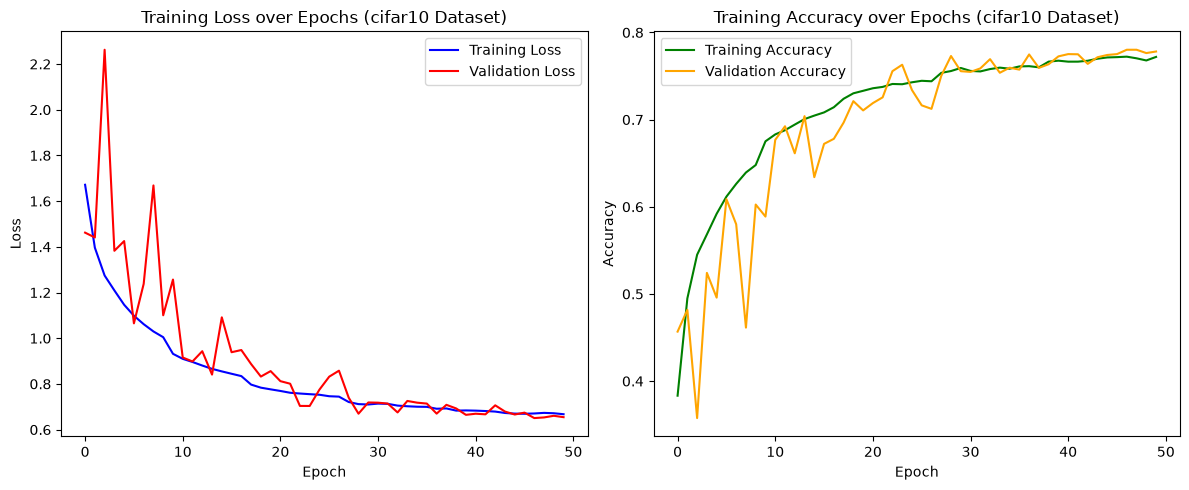

In [6]:
HISTORY_PATH = f"../saved_models/lenet5_{DATASET_NAME}_history.csv"

if os.path.exists(HISTORY_PATH):
    # Load history from CSV file into a Pandas DataFrame
    history_df = pd.read_csv(HISTORY_PATH)
    print("Training history loaded successfully.")
    display(history_df.head())
else:
    raise FileNotFoundError(f"History file not found at: {HISTORY_PATH}")

# Plot training & validation loss and accuracy curves across epochs
plot_training_hist_df(history_df, dataset_name=DATASET_NAME)

In [7]:
trainer = LeNetTrainer(model=model)

# Evaluate model performance on unseen test data
results = trainer.evaluate(test_ds, dataset_name=DATASET_NAME)

print(f"Test Accuracy ({DATASET_NAME.upper()}): {results['accuracy'] * 100:.2f}%")
print(f"Test Loss ({DATASET_NAME.upper()}): {results['loss']:.4f}")

--- Evaluating LeNet-5 Plus on (cifar10) Test Data ---
157/157 ━━━━━━━━━━━━━━━━━━━━ 31s 192ms/step - accuracy: 0.7671 - loss: 0.6628 - top_2_accuracy: 0.9006
Test Accuracy (CIFAR10): 76.71%
Test Loss (CIFAR10): 0.6628


157/157 ━━━━━━━━━━━━━━━━━━━━ 42s 263ms/step


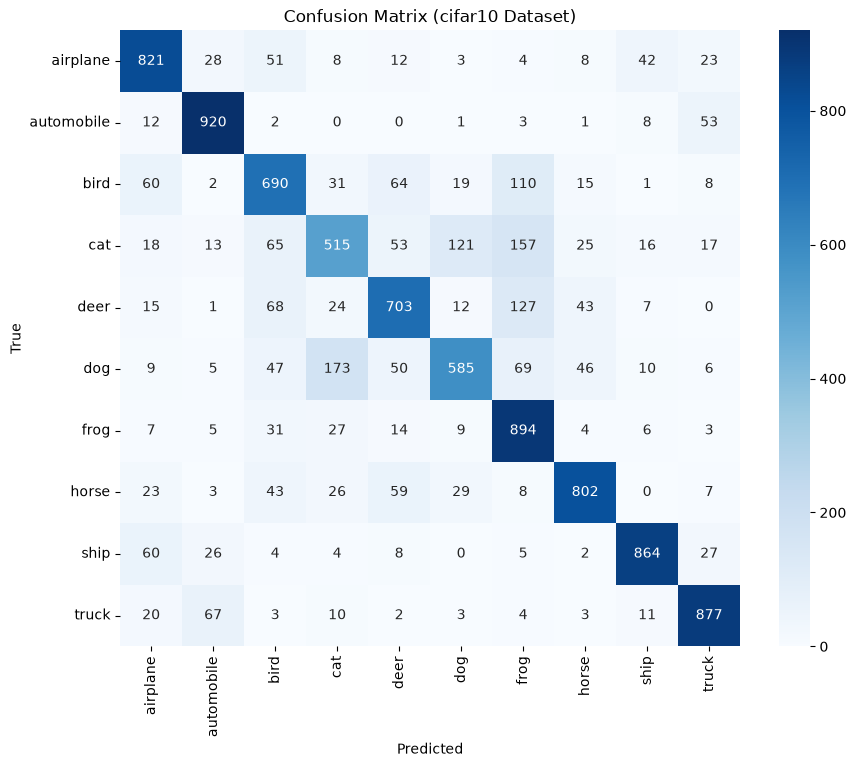

In [8]:
# Generate and display normalized confusion matrix heatmap
plot_confusion_matrix(model=model, dataset=test_ds, dataset_name=DATASET_NAME)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step


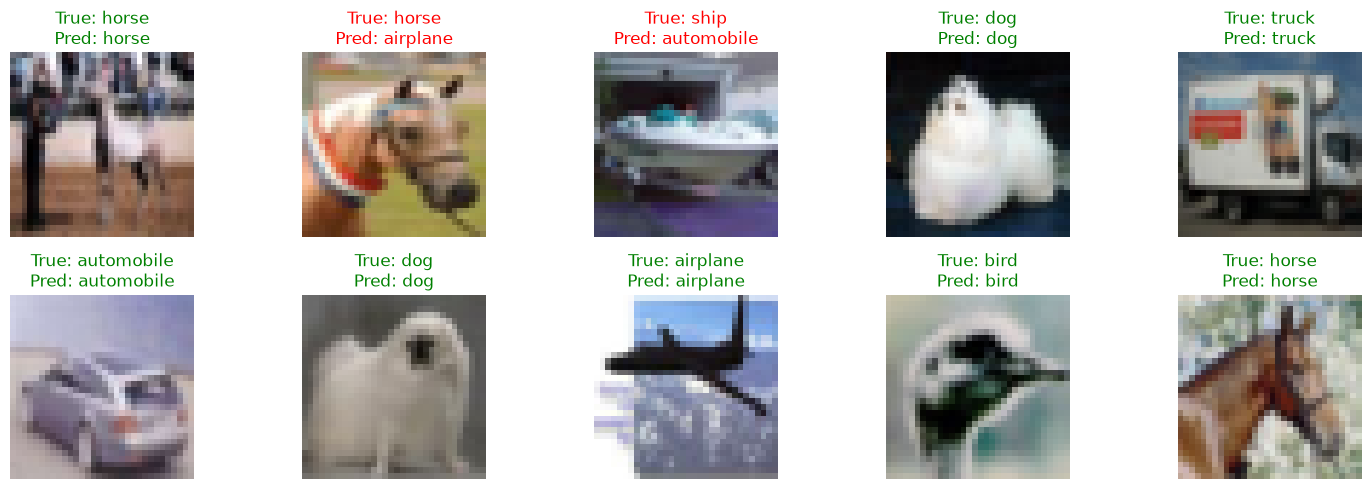

In [9]:
# Visualize random test set samples with green/red prediction status labels
plot_sample_predictions(
    model=model,
    dataset=test_ds,
    dataset_name=DATASET_NAME,
    num_samples=10
)